# 📊 **User Demographics and Physical Profile Analysis**

# 1. **Project Overview**

This project analyzes user demographic and physical profile data obtained from the DummyJSON API.

The analysis focuses on exploring user characteristics such as:

* Age distribution
* Gender Balance
* Geographic distribution
* Physical attributes like height and weight
* Relationships between variables

The goal is to demonstrate a full **data analysis workflow in Python**, including:

* API data collection
* Data cleaning and preparation
* Exploratory data analysis (EDA)
* Data visualization using **Seaborn and Matplotlib**
* Interpretation of insights

## **Table of content**:

1. Project Overview
2. Import Required Libraries
3. Data Collection from API
4. Initial Data Inspection
5. Data Cleaning and Feature Engineering
6. Data Analysis
    * Question 1 — Average Age of Users 
    * Question 2 — Average Age by Gender
    * Question 3 — User Count by Gender
    * Question 4 — Top 10 Cities with the Most Us...
    * Question 5 — Average Height and Weight
    * Question 6 — Relationship Between Age and 
7. Additional Insights (Bonus Analysis)
8. Key Findings
9. Conclusion

# 2. Import Required Libraries

In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json


# 3. Data Collection from API

The dataset is retrieved from the DummyJSON Users API.

API Endpoint:

```
https://dummyjson.com/users?limit=26
```

This endpoint returns user demographic and profile information in JSON format.

In [118]:
# There is already a separate python file for reading the data called 'reading_users_data.py'

df = pd.read_csv('users.csv')
df.head()

,id,firstName,lastName,maidenName,age,gender,email,phone,username,password,...,address,macAddress,university,bank,company,ein,ssn,userAgent,crypto,role
0,1,Emily,Johnson,Smith,29,female,emily.johnson@x.dummyjson.com,+81 965-431-3024,emilys,emilyspass,...,"{'address': '626 Main Street', 'city': 'Phoeni...",47:fa:41:18:ec:eb,University of Wisconsin--Madison,"{'cardExpire': '05/28', 'cardNumber': '3693233...","{'department': 'Engineering', 'name': 'Dooley,...",977-175,900-590-289,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin
1,2,Michael,Williams,NaN,36,male,michael.williams@x.dummyjson.com,+49 258-627-6644,michaelw,michaelwpass,...,"{'address': '385 Fifth Street', 'city': 'Houst...",79:15:78:99:60:aa,Ohio State University,"{'cardExpire': '01/30', 'cardNumber': '3530633...","{'department': 'Support', 'name': 'Spinka - Di...",912-602,108-953-962,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin
2,3,Sophia,Brown,NaN,43,female,sophia.brown@x.dummyjson.com,+81 210-652-2785,sophiab,sophiabpass,...,"{'address': '1642 Ninth Street', 'city': 'Wash...",12:a3:d3:6f:5c:5b,Pepperdine University,"{'cardExpire': '10/27', 'cardNumber': '6011212...","{'department': 'Research and Development', 'na...",963-113,638-461-822,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin
3,4,James,Davis,NaN,46,male,james.davis@x.dummyjson.com,+49 614-958-9364,jamesd,jamesdpass,...,"{'address': '238 Jefferson Street', 'city': 'S...",10:7d:df:1f:97:58,University of Southern California,"{'cardExpire': '07/30', 'cardNumber': '5303440...","{'department': 'Support', 'name': 'Pagac and S...",904-810,116-951-314,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin
4,5,Emma,Miller,Johnson,31,female,emma.miller@x.dummyjson.com,+91 759-776-1614,emmaj,emmajpass,...,"{'address': '607 Fourth Street', 'city': 'Jack...",32:b9:7e:8d:f5:e8,Northeastern University,"{'cardExpire': '07/30', 'cardNumber': '5237188...","{'department': 'Human Resources', 'name': 'Gra...",403-505,526-210-885,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:9...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin


# 4. Initial Data Inspection

Understanding the dataset structure before cleaning or analysis.

Basic Data Exploration: 
* Shape of the DataFrame  
* List of all column names
* Data types of each column  
* Number of missing values per column (isnull().sum())
* Number of duplicate rows (duplicated().sum())
* Summary statistics for numeric columns (describe())
* Value counts for important categorical columns (e.g. gender, bloodGroup, eyeColor, role, address.country)

In [119]:
# shape of the DataFrame
print(f"DF shape: {df.shape} \n{'-'*100}")

# List of column names
print(f"Column Names:\n{df.columns}\n{'-'*100}")

# Data types of each column
print(f"Columns' Data types:\n{df.dtypes}\n{'-'*100}")



DF shape: (208, 28) 
----------------------------------------------------------------------------------------------------
Column Names:
Index(['id', 'firstName', 'lastName', 'maidenName', 'age', 'gender', 'email',
       'phone', 'username', 'password', 'birthDate', 'image', 'bloodGroup',
       'height', 'weight', 'eyeColor', 'hair', 'ip', 'address', 'macAddress',
       'university', 'bank', 'company', 'ein', 'ssn', 'userAgent', 'crypto',
       'role'],
      dtype='object')
----------------------------------------------------------------------------------------------------
Columns' Data types:
id              int64
firstName      object
lastName       object
maidenName     object
age             int64
gender         object
email          object
phone          object
username       object
password       object
birthDate      object
image          object
bloodGroup     object
height        float64
weight        float64
eyeColor       object
hair           object
ip             object

In [120]:
# Number of missing values per column
print(f"Number of missing values per column:\n{ df.isnull().sum() }\n{'-'*100}")

# Number of duplicate rows 
print(f"Number of duplicate rows:\n{ df.duplicated().sum() }\n{'-'*100}")

# Summary statistics for numeric columns
print(f"Summary statistics:\n{ df.describe() }\n{'-'*100}")

# Value counts for important categorical columns (e.g. gender, bloodGroup, eyeColor, role, address.country)

print(f"Value counts:\n{ df['gender'].value_counts()}\n{'-'*100}")

Number of missing values per column:
id              0
firstName       0
lastName        0
maidenName    148
age             0
gender          0
email           0
phone           0
username        0
password        0
birthDate       0
image           0
bloodGroup      0
height          0
weight          0
eyeColor        0
hair            0
ip              0
address         0
macAddress      0
university      0
bank            0
company         0
ein             0
ssn             0
userAgent       0
crypto          0
role            0
dtype: int64
----------------------------------------------------------------------------------------------------
Number of duplicate rows:
0
----------------------------------------------------------------------------------------------------
Summary statistics:
               id         age      height      weight
count  208.000000  208.000000  208.000000  208.000000
mean   104.500000   33.139423  175.720240   75.038606
std     60.188592    5.544269   14

* The dataset contains demographic and profile attributes.
* **maidenName** column is the most one containing missing values (more than 50%)  
* Numeric features include **age, height, and weight**.
* Categorical features include **gender, blood group, eye color, and role**.

# 5. Data Cleaning and Feature Engineering



Data Cleaning / Preparation (if needed)
* Some columns contain **nested dictionaries**, particularly the address column.
We extract useful fields like **city, state, and country**. using .apply() and json.loads if necessary
* Handle missing values in age, height, weight 


Dropping 'maidenName' column since it contains a lot of missing values


In [121]:
# Dropping 'maidenName' column since it contains a lot of missing values
# del df['maidenName']
cleaned_df = df.drop('maidenName', axis= 1)

# check the column is dropped
print(df.columns)

cleaned_df.columns

Index(['id', 'firstName', 'lastName', 'maidenName', 'age', 'gender', 'email',
       'phone', 'username', 'password', 'birthDate', 'image', 'bloodGroup',
       'height', 'weight', 'eyeColor', 'hair', 'ip', 'address', 'macAddress',
       'university', 'bank', 'company', 'ein', 'ssn', 'userAgent', 'crypto',
       'role'],
      dtype='object')


Index(['id', 'firstName', 'lastName', 'age', 'gender', 'email', 'phone',
       'username', 'password', 'birthDate', 'image', 'bloodGroup', 'height',
       'weight', 'eyeColor', 'hair', 'ip', 'address', 'macAddress',
       'university', 'bank', 'company', 'ein', 'ssn', 'userAgent', 'crypto',
       'role'],
      dtype='object')

#### Parsing `address` column and extracing `city` from it as a new column

In [122]:
def parse_address(addr_str):
    try:
        addr_dict = json.loads(addr_str.replace("'", "\""))  # fix single quotes to double
        return addr_dict.get('city', 'Unknown')              # .get() is used to avoid errors while searching for a dict key
    except:
        return 'Unknown'

cleaned_df['city'] = df['address'].apply(parse_address)

# count how many rows (users) belong to each city, and renaming the count column to user_count
city_counts = cleaned_df.groupby('city').size().reset_index(name='User_Count')

# showing cities with most users at the top
city_counts = city_counts.sort_values('User_Count', ascending=False)

print(cleaned_df.shape)

# top 10 cities
city_counts.head(10) 

(208, 28)


,city,User_Count
13,Phoenix,17
4,Dallas,15
10,Los Angeles,14
9,Jacksonville,14
18,Seattle,12
2,Chicago,11
3,Columbus,11
17,San Jose,11
1,Charlotte,11
11,New York,11


Creating a **full_name column**.

In [123]:
# Creating a new column 'full_name'
cleaned_df['full_name'] = df['firstName'] + ' ' + df['lastName']

print(cleaned_df.columns)
print('DF shape:', cleaned_df.shape)

cleaned_df[['full_name']].head()

Index(['id', 'firstName', 'lastName', 'age', 'gender', 'email', 'phone',
       'username', 'password', 'birthDate', 'image', 'bloodGroup', 'height',
       'weight', 'eyeColor', 'hair', 'ip', 'address', 'macAddress',
       'university', 'bank', 'company', 'ein', 'ssn', 'userAgent', 'crypto',
       'role', 'city', 'full_name'],
      dtype='object')
DF shape: (208, 29)


,full_name
0,Emily Johnson
1,Michael Williams
2,Sophia Brown
3,James Davis
4,Emma Miller


duplicates were checked and none were found

missing values were assessed

**maidenName** is the main missing field and not critical for the required analysis so I droped it

nested address information was extracted into usable columns (city)

numeric columns were validated before plotting


# 6. Data Analysis 

Required Analysis:
1. What is the average age of users?
2. Average age by gender?
3. Number of users per gender?
4. Top 10 cities with the most users?
5. Average height and weight overall?
6. Is there any obvious relationship between age and height/weight?

In [ ]:
# Setting the global style and context of the visualizations

# Other popular options
sns.set_style("darkgrid")     # dark background with grid

# Best for presentations / notebooks
sns.set_context("notebook")         #, font_scale=1.3)
 

# Set once for all plots
sns.set_palette("viridis")          # bright, distinct colors
 

## Question 1 — Average Age of Users
**The average age** of users represents the typical age of users in the data.

### Distribution of Age
**The age distribution shows how users are spread across different age ranges.**

The average age: 33



c:\Users\hp\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


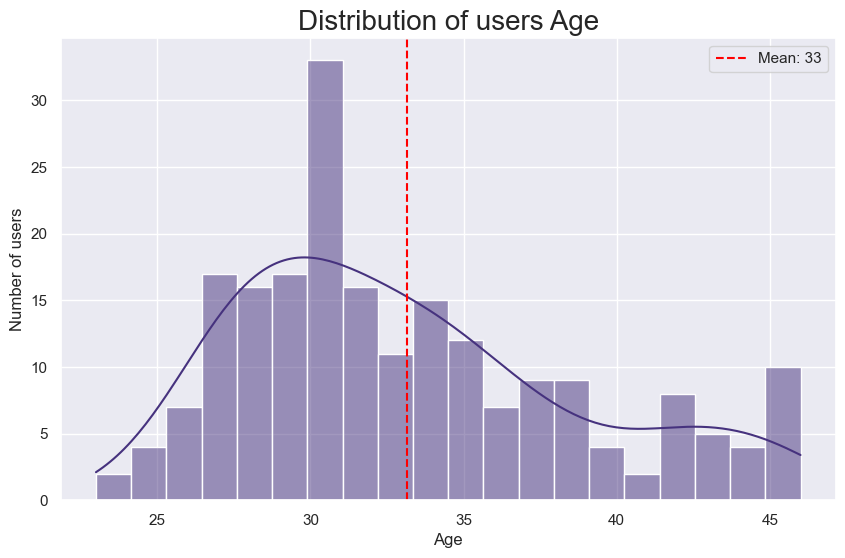

In [204]:
# 3. Add vertical lines for mean and median using Matplotlib's axvline
age_avg= cleaned_df['age'].dropna().mean()
print(f"The average age: {age_avg:.0f}\n")

sns.histplot(cleaned_df, 
             x= 'age', 
             bins= 20, 
            #  color='teal', 
             kde= True,     # Kernel Density Estimate to add a smoothed continuous probability curve
             )

# adding a virtical line for highlighting the average age value
plt.axvline(age_avg, color='r', linestyle='--', label=f'Mean: {age_avg:.0f}')

plt.title('Distribution of users Age', fontsize= 20)
plt.xlabel('Age')
plt.ylabel('Number of users')
plt.legend()

plt.show()

#### Insight

The distribution shows that most users fall between **25 and 40 years old**, indicating a relatively young user population.
#### Key Result

**Average Age of Users:** 33 years

## Question 2 — Average Age by Gender
 
This comparison shows whether there is a difference in age distribution between genders.

In [195]:
age_avg_by_gender= cleaned_df.groupby('gender')['age'].mean().round(0)

print(age_avg_by_gender) 


gender
female    31.0
male      35.0
Name: age, dtype: float64


Visualization

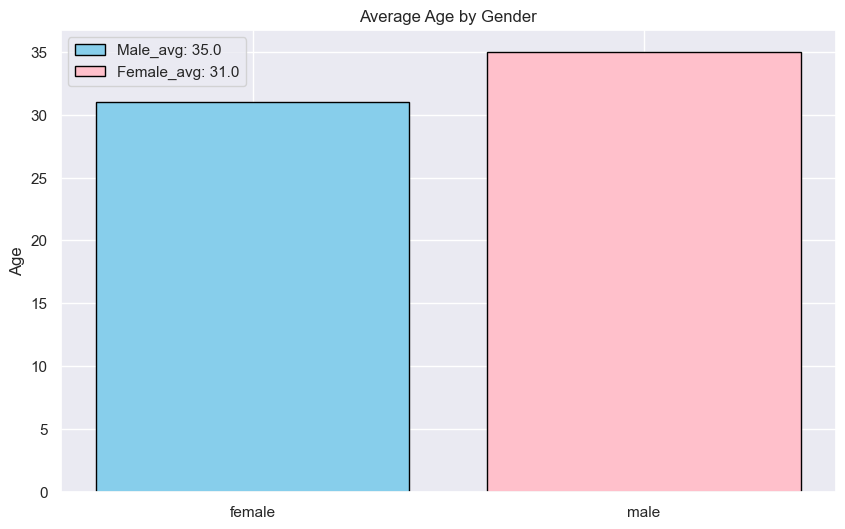

In [ ]:
bars = plt.bar( age_avg_by_gender.index, age_avg_by_gender.values, color= ['skyblue', 'pink'], edgecolor= 'black')
labels = [ f"Male_avg: {age_avg_by_gender['male']}",
          f"Female_avg: {age_avg_by_gender['female']}"
]

plt.title('Average Age by Gender', fontsize= 20)
plt.ylabel('Age')

plt.legend(bars, labels)
plt.show()

## Question 3 — User Count by Gender

Number of users per gender

Comparing the number of users for each gender 
To know **the gender balance for the dataset**.

In [197]:
count_by_gender= cleaned_df['gender'].value_counts()

print(count_by_gender) 

gender
female    106
male      102
Name: count, dtype: int64


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


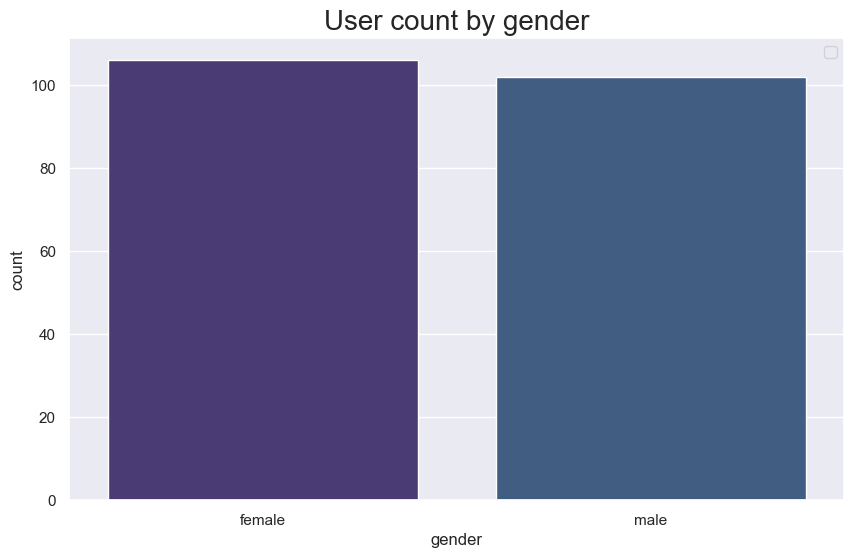

In [203]:
sns.countplot(data= cleaned_df, x= 'gender')
plt.title('User count by gender', fontsize= 20)
plt.legend()

plt.show()

## Question 4 — Top 10 Cities with the Most Users



In [ ]:
city_counts = cleaned_df.groupby('city').size().reset_index(name= 'user_counts')
top10 = city_counts.sort_values('user_counts', ascending= False).head(10)
top10

# or

# top_cities = cleaned_df['city'].value_counts()
# top10 = top_cities.sort_values(ascending= False).head(10)
# top10

,city,user_counts
13,Phoenix,17
4,Dallas,15
10,Los Angeles,14
9,Jacksonville,14
18,Seattle,12
2,Chicago,11
3,Columbus,11
17,San Jose,11
1,Charlotte,11
11,New York,11


**This analysis identifies the locations with the highest number of users.**

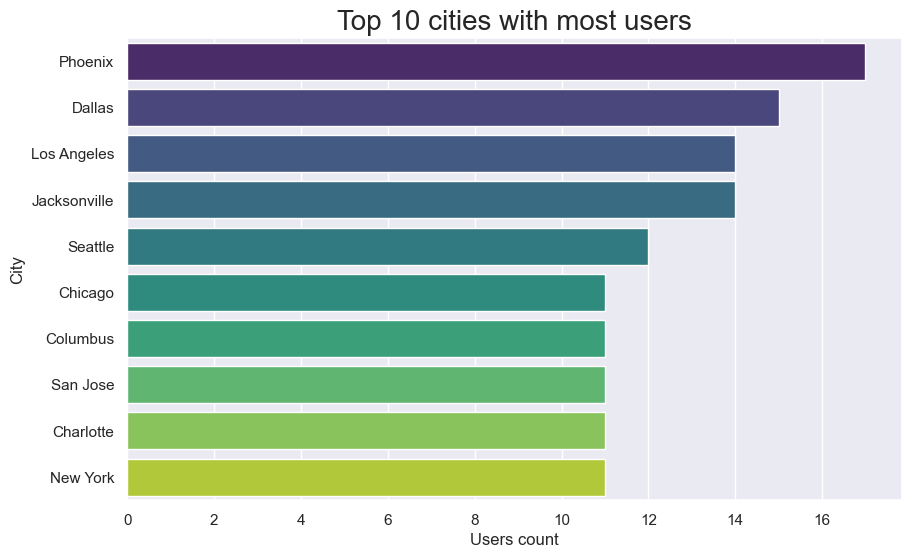

In [212]:
sns.barplot(data= top10, 
            x= 'user_counts', 
            y= 'city', 
            palette= 'viridis')

plt.title('Top 10 cities with most users', fontsize= 20)
plt.xlabel('Users count')
plt.ylabel('City')

plt.show()

## Question 5 — Average Height and Weight


**Height and weight averages provide insight into the physical characteristics of the users.**

Average Height: 175.7
----------------------------------------------------------------------------------------------------

Average Weight: 75.0
----------------------------------------------------------------------------------------------------


Text(0, 0.5, 'Values (cm / kg)')

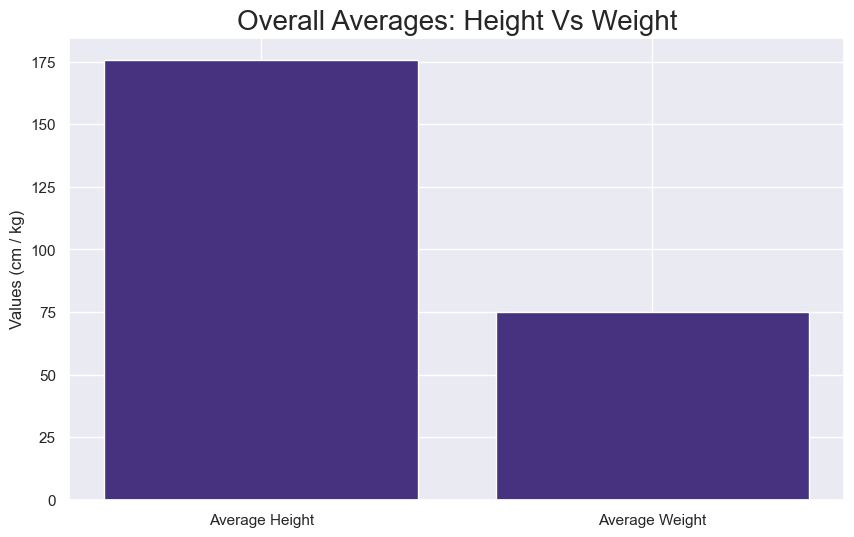

In [ ]:
avg_height = cleaned_df['height'].mean().round(1)
print(f"Average Height: {avg_height}\n{'-'*100}\n")

avg_weight = cleaned_df['weight'].mean().round(1)
print(f"Average Weight: {avg_weight}\n{'-'*100}\n")


labels = ['Average Height', 'Average Weight']
values = [avg_height, avg_weight]

plt.bar(labels, values) 

plt.title('Overall Averages: Height Vs Weight', fontsize= 20)

plt.ylabel('Values (cm / kg)')

### Key Result

**Average Height:** 175.72 cm  
**Average Weight:** 75.04 kg

## Question 6 — Relationship Between Age and Height / Weight
The scatter plots and correlation values help determine whether age is related to height or weight.


### Age vs Height

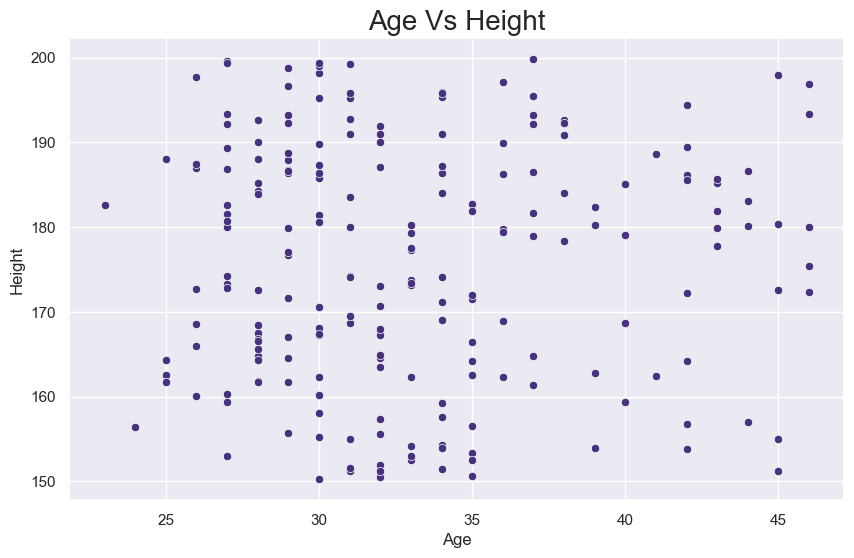

In [238]:
sns.scatterplot(data= cleaned_df, x= 'age', y= 'height')

plt.title('Age Vs Height', fontsize= 20)
plt.xlabel('Age')
plt.ylabel('Height') 

plt.show()

### Age vs Weight  

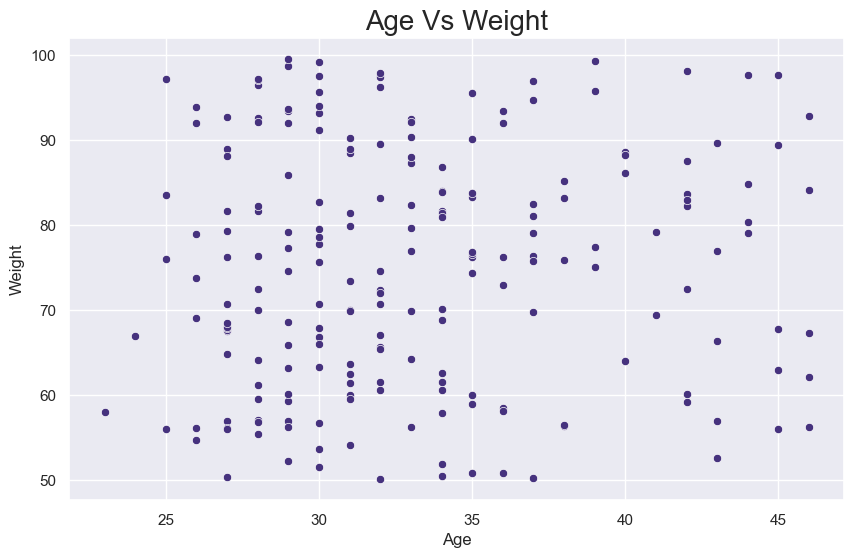

In [239]:
sns.scatterplot(data= cleaned_df, x= 'age', y= 'weight')

plt.title('Age Vs Weight', fontsize= 20)
plt.xlabel('Age')
plt.ylabel('Weight')

plt.show()


### Correlation between Age and Height/Weight.

             age    height    weight
age     1.000000  0.023458  0.067026
height  0.023458  1.000000 -0.088655
weight  0.067026 -0.088655  1.000000


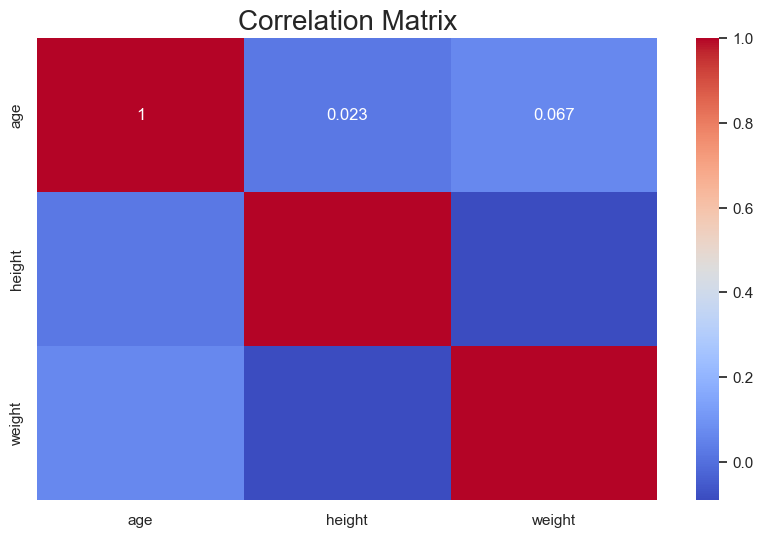

In [277]:
cols = ['age', 'height', 'weight']
corr_matrix = cleaned_df[cols].corr()
print(corr_matrix)

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

plt.title("Correlation Matrix", fontsize= 20)

plt.show()

As obvious from the scatterplots and heatmap **there is a weak relation between 'Age' and 'height'/'weight'**

# 7. Additional Insights (Bonus Analysis)

These additional analyses help understand other demographic characteristics.

## Blood Group Distribution 

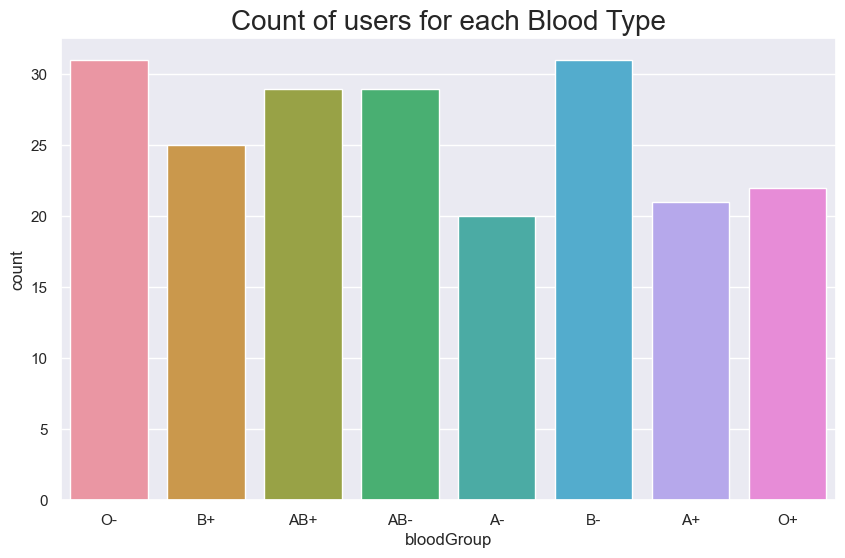

In [ ]:
sns.countplot(data= cleaned_df, x= 'bloodGroup')

plt.title('Count of users for each Blood Type', fontsize= 20)

plt.show()

## Eye Color Distribution

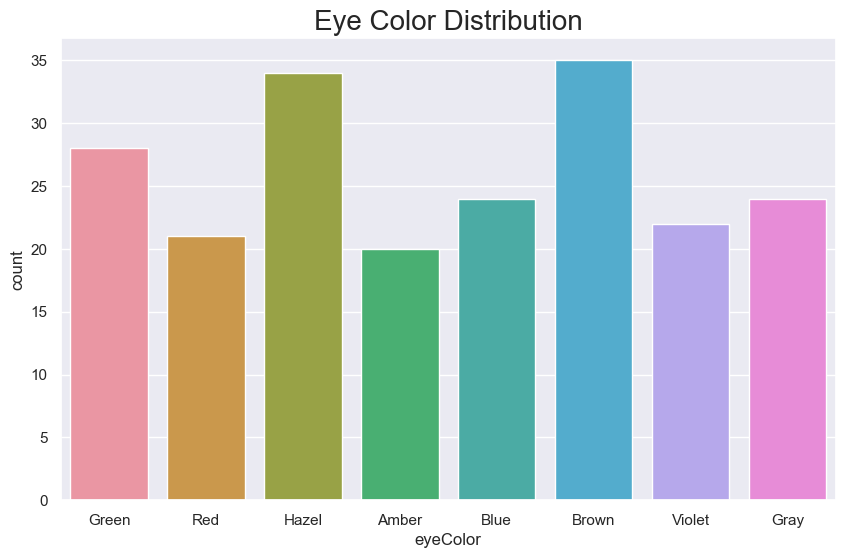

In [267]:
sns.countplot(cleaned_df, x= 'eyeColor')
plt.title('Eye Color Distribution', fontsize= 20)

plt.show()

## Height by Gender

Shows the difference in height between Males and Females

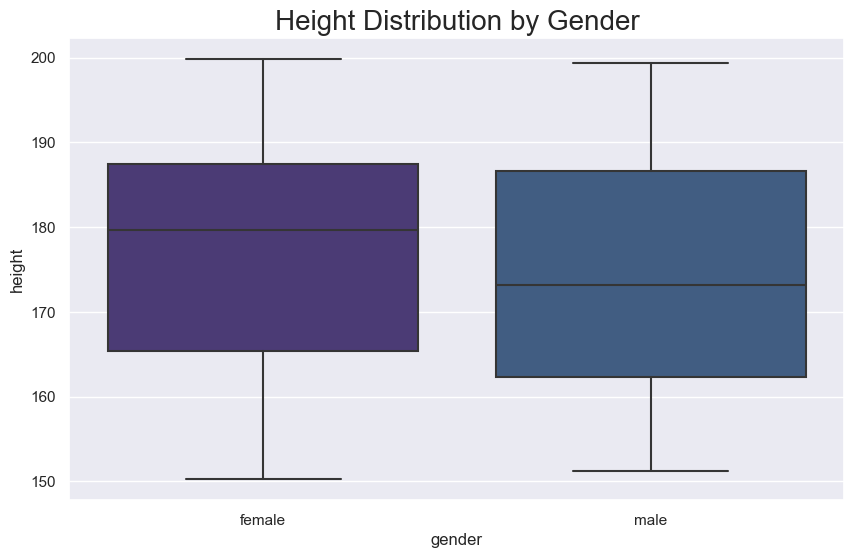

In [228]:
avg_height = cleaned_df['height'].mean().round(1)
# print(f"Average Height: {avg_height}\n{'-'*100}\n")

avg_weight = cleaned_df['weight'].mean().round(1)
# print(f"Average Weight: {avg_weight}\n{'-'*100}\n")

sns.boxplot(x="gender", y="height", data=cleaned_df)

plt.title("Height Distribution by Gender", fontsize= 20)

plt.show()

## Role Distribution by Gender 

gender  role     
female  user         98
        moderator     5
        admin         3
male    user         95
        moderator     5
        admin         2
Name: count, dtype: int64


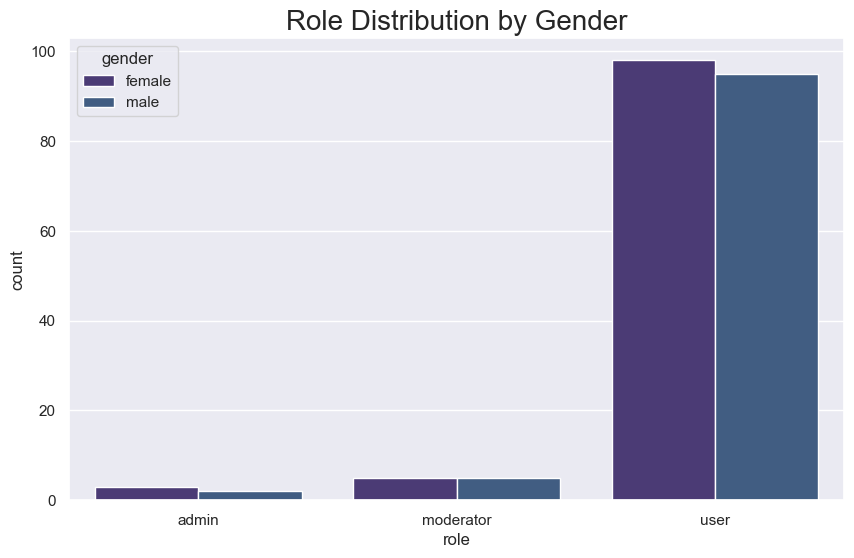

In [276]:
role_by_gender = cleaned_df.groupby('gender')['role'].value_counts()
print(role_by_gender)

sns.countplot(cleaned_df, x= 'role', hue= 'gender')
plt.title('Role Distribution by Gender', fontsize= 20)
plt.show()

# 8. Key Findings

Key insights include: 

* The dataset contains demographic and physical attributes of users.
* The average user age is approximately **33 years**.
* Most users fall between ages 25 and 40.
* The gender distribution is relatively balanced.
* Some cities contain higher concentrations of users.
* Height and weight averages describe the physical profile of users.
* Age shows little correlation with height or weight.

# 9. Conclusion

This project demonstrated a complete **Python data analysis workflow**, including:

* Data collection from an API
* Data cleaning and preparation
* Exploratory data analysis
* Visualization using Seaborn & Matplotlib
* Interpretation of findings

The analysis provides a demographic overview of users and illustrates how Python tools can be used to derive insights from structured data.